# RQ3: Clustering — Campaign-Customer Segment Discovery

**Research Question:** What natural groupings of campaigns exist when simultaneously considering spending behavior, performance metrics, and customer subscription attributes, and what are the distinguishing characteristics of each cluster?

**Task:** Unsupervised Clustering  
**Target:** None (unsupervised)  
**Models:** K-Means, Agglomerative Hierarchical Clustering, DBSCAN  
**Dataset:** Marketing and Product Performance Dataset (Kaggle)

In [55]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
sns.set_palette(PALETTE)
RANDOM_STATE = 42
OUTPUT_DIR = '/kaggle/working/'

def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format='pdf', bbox_inches='tight', dpi=300)
    plt.close(fig)
    print(f'Saved figure: {path}')

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f'Saved table:  {path}')

print('Imports OK')

Imports OK


## 1. Data Loading

In [56]:
input_dir = '/kaggle/input'
data_files = [
    os.path.join(root, f)
    for root, dirs, files in os.walk(input_dir)
    for f in files if f.endswith('.xlsx') or f.endswith('.xls') or f.endswith('.csv')
]
print('Found files:', data_files)
FILE_PATH = data_files[0]

df = pd.read_csv(FILE_PATH) if FILE_PATH.endswith('.csv') else pd.read_excel(FILE_PATH)
print(f'Shape: {df.shape}')
df['Has_Flash_Sale'] = df['Flash_Sale_ID'].notna().astype(int)
df['Has_Bundle']     = df['Bundle_ID'].notna().astype(int)
df['Conversion_Rate'] = np.where(df['Clicks'] > 0, df['Conversions'] / df['Clicks'], 0)
df.head()

Found files: ['/kaggle/input/datasets/vanishjr/marketing-product-performance/marketing_and_product_performance.csv']
Shape: (10000, 17)


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords,Has_Flash_Sale,Has_Bundle,Conversion_Rate
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable,1,1,0.014759
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative,1,1,0.894737
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable,1,1,0.074732
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable,1,1,0.303537
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable,1,1,0.096577


## 2. Feature Selection & Preprocessing

In [57]:
CLUSTER_FEATURES = [
    'Budget', 'Clicks', 'Conversions', 'Revenue_Generated', 'ROI',
    'Units_Sold', 'Bundle_Price', 'Discount_Level',
    'Subscription_Length', 'Conversion_Rate',
    'Customer_Satisfaction_Post_Refund'
]

X_raw = df[CLUSTER_FEATURES].copy()

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f'Clustering matrix shape: {X_scaled.shape}')

Clustering matrix shape: (10000, 11)


## 3. PCA Dimensionality Reduction

PCA 2D explained variance: 21.69%


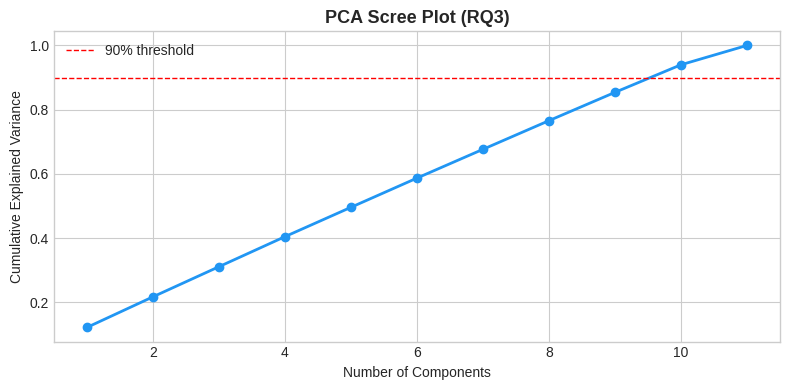

In [58]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
explained_var = np.cumsum(pca_full.explained_variance_ratio_)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_scaled)
print(f'PCA 2D explained variance: {pca_2d.explained_variance_ratio_.sum():.2%}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(explained_var)+1), explained_var, marker='o', color=PALETTE[0], linewidth=2)
ax.axhline(0.9, color='red', linestyle='--', linewidth=1, label='90% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Scree Plot (RQ3)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Optimal K Selection (Elbow + Silhouette)

In [59]:
inertias, sil_scores = [], []
K_RANGE = range(2, 13)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inertias, marker='o', color=PALETTE[0], linewidth=2)
axes[0].set_title('Elbow Method — K-Means Inertia (RQ3)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_RANGE), sil_scores, marker='s', color=PALETTE[1], linewidth=2)
axes[1].set_title('Silhouette Score vs K (RQ3)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
save_figure(fig, 'rq3_optimal_k_selection.pdf')
plt.show()

OPTIMAL_K = list(K_RANGE)[np.argmax(sil_scores)]
print(f'Optimal K (best silhouette): {OPTIMAL_K}')

Saved figure: /kaggle/working/rq3_optimal_k_selection.pdf
Optimal K (best silhouette): 2


## 5. K-Means Clustering

In [60]:
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=20)
km_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = km_labels

km_sil = silhouette_score(X_scaled, km_labels)
km_db  = davies_bouldin_score(X_scaled, km_labels)
km_ch  = calinski_harabasz_score(X_scaled, km_labels)
print(f'K-Means  — Silhouette: {km_sil:.4f}  Davies-Bouldin: {km_db:.4f}  Calinski-Harabasz: {km_ch:.1f}')

K-Means  — Silhouette: 0.0774  Davies-Bouldin: 3.4374  Calinski-Harabasz: 783.0


## 6. Agglomerative Hierarchical Clustering

In [61]:
# Sample for linkage if dataset is large (dendrograms are slow on >5k rows)
MAX_DENDRO = 5000
if len(X_scaled) > MAX_DENDRO:
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(X_scaled), MAX_DENDRO, replace=False)
    X_dendro = X_scaled[idx]
else:
    X_dendro = X_scaled

Z = linkage(X_dendro, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, ax=ax,
           color_threshold=Z[-OPTIMAL_K, 2],
           above_threshold_color='grey', leaf_font_size=8)
ax.set_title('Agglomerative Hierarchical Clustering Dendrogram (RQ3)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Index (truncated)')
ax.set_ylabel('Ward Linkage Distance')
ax.axhline(Z[-OPTIMAL_K, 2], color='red', linestyle='--', linewidth=1.5, label=f'Cut for K={OPTIMAL_K}')
ax.legend(fontsize=10)
plt.tight_layout()
save_figure(fig, 'rq3_dendrogram.pdf')
plt.show()

Saved figure: /kaggle/working/rq3_dendrogram.pdf


In [62]:
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

agg_sil = silhouette_score(X_scaled, agg_labels)
agg_db  = davies_bouldin_score(X_scaled, agg_labels)
agg_ch  = calinski_harabasz_score(X_scaled, agg_labels)
print(f'Agglomerative — Silhouette: {agg_sil:.4f}  Davies-Bouldin: {agg_db:.4f}  Calinski-Harabasz: {agg_ch:.1f}')

Agglomerative — Silhouette: 0.4431  Davies-Bouldin: 1.2530  Calinski-Harabasz: 599.6


## 7. DBSCAN

In [63]:
# Estimate eps using k-distance graph
k_nn = 5
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k_nn - 1])

# Use 95th percentile as eps
eps_est = float(np.percentile(k_distances, 95))
print(f'Estimated eps (95th pct of {k_nn}-NN distance): {eps_est:.4f}')

dbs = DBSCAN(eps=eps_est, min_samples=5, n_jobs=-1)
dbs_labels = dbs.fit_predict(X_scaled)

n_clusters_dbs = len(set(dbs_labels)) - (1 if -1 in dbs_labels else 0)
n_noise        = (dbs_labels == -1).sum()
print(f'DBSCAN clusters found: {n_clusters_dbs}  |  Noise points: {n_noise} ({n_noise/len(dbs_labels):.1%})')

if n_clusters_dbs > 1:
    mask_valid = dbs_labels != -1
    dbs_sil = silhouette_score(X_scaled[mask_valid], dbs_labels[mask_valid])
    dbs_db  = davies_bouldin_score(X_scaled[mask_valid], dbs_labels[mask_valid])
    print(f'DBSCAN — Silhouette: {dbs_sil:.4f}  Davies-Bouldin: {dbs_db:.4f}')
else:
    dbs_sil, dbs_db = None, None
    print('DBSCAN found only 1 cluster — metrics not applicable')

Estimated eps (95th pct of 5-NN distance): 1.9801
DBSCAN clusters found: 2  |  Noise points: 206 (2.1%)
DBSCAN — Silhouette: 0.2611  Davies-Bouldin: 0.9768


## 8. Method Comparison & PCA Scatter

In [64]:
method_data = {
    'Method':              ['K-Means', 'Agglomerative', 'DBSCAN'],
    'N_Clusters':          [OPTIMAL_K, OPTIMAL_K, n_clusters_dbs],
    'Silhouette':          [round(km_sil, 4), round(agg_sil, 4), round(dbs_sil, 4) if dbs_sil else None],
    'Davies_Bouldin':      [round(km_db, 4),  round(agg_db, 4),  round(dbs_db, 4) if dbs_db else None],
    'Calinski_Harabasz':   [round(km_ch, 1),  round(agg_ch, 1),  None]
}
method_df = pd.DataFrame(method_data)
print(method_df.to_string(index=False))

# Bar chart comparison
valid_methods = method_df.dropna(subset=['Silhouette'])
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(valid_methods['Method'], valid_methods['Silhouette'],
       color=PALETTE[:len(valid_methods)], edgecolor='white', width=0.5)
ax.set_title('Silhouette Score by Clustering Method (RQ3)', fontsize=13, fontweight='bold')
ax.set_ylabel('Silhouette Score (higher = better)')
for i, (_, row) in enumerate(valid_methods.iterrows()):
    ax.text(i, row['Silhouette'] + 0.002, f"{row['Silhouette']:.4f}", ha='center', fontsize=10)
plt.tight_layout()
save_figure(fig, 'rq3_clustering_method_comparison.pdf')
plt.show()

       Method  N_Clusters  Silhouette  Davies_Bouldin  Calinski_Harabasz
      K-Means           2      0.0774          3.4374              783.0
Agglomerative           2      0.4431          1.2530              599.6
       DBSCAN           2      0.2611          0.9768                NaN
Saved figure: /kaggle/working/rq3_clustering_method_comparison.pdf


In [65]:
# PCA scatter plot colored by K-Means clusters
cmap = plt.cm.get_cmap('tab10', OPTIMAL_K)
fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=km_labels, cmap='tab10', alpha=0.5, s=15, edgecolors='none')

# Cluster centroids in PCA space
centroids_pca = pca_2d.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='black', s=150, marker='X', label='Centroids', zorder=5)
for i, (cx, cy) in enumerate(centroids_pca):
    ax.annotate(f'C{i}', (cx, cy), textcoords='offset points', xytext=(6, 4), fontsize=9, fontweight='bold')

legend = ax.legend(*scatter.legend_elements(), title='Cluster', loc='upper right', fontsize=9)
ax.add_artist(legend)
ax.legend(loc='upper left', fontsize=9)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
ax.set_title(f'K-Means Clusters in PCA Space (K={OPTIMAL_K}, RQ3)', fontsize=13, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'rq3_pca_cluster_scatter.pdf')
plt.show()

Saved figure: /kaggle/working/rq3_pca_cluster_scatter.pdf


## 9. Cluster Profiling

In [66]:
profile_agg = {col: 'mean' for col in CLUSTER_FEATURES}
profile_df = df.groupby('KMeans_Cluster').agg(profile_agg).round(4)
profile_df['Dominant_Subscription_Tier'] = (
    df.groupby('KMeans_Cluster')['Subscription_Tier'].agg(lambda x: x.mode()[0])
)
profile_df['Has_Flash_Sale_Rate'] = (
    df.groupby('KMeans_Cluster')['Has_Flash_Sale'].mean().round(3)
)
profile_df['Count'] = df.groupby('KMeans_Cluster').size()
profile_df['Pct']   = (profile_df['Count'] / len(df) * 100).round(2)
profile_df.index.name = 'Cluster'
profile_df = profile_df.reset_index()

save_table(profile_df, 'rq3_cluster_profiles.csv')
profile_df

Saved table:  /kaggle/working/rq3_cluster_profiles.csv


,Cluster,Budget,Clicks,Conversions,Revenue_Generated,ROI,Units_Sold,Bundle_Price,Discount_Level,Subscription_Length,Conversion_Rate,Customer_Satisfaction_Post_Refund,Dominant_Subscription_Tier,Has_Flash_Sale_Rate,Count,Pct
0,0,25317.4085,2466.5849,500.1223,49934.0555,2.7535,100.4701,273.8695,39.2327,17.9003,0.5938,3.5029,Basic,1.0,4963,49.63
1,1,25210.5969,2496.9972,497.8519,50141.6634,2.7592,100.9059,276.5077,39.6065,18.1310,0.6255,1.5136,Basic,1.0,5037,50.37


## 10. Conclusions

In [67]:
print('=' * 60)
print('RQ3 CONCLUSION')
print('=' * 60)
print(f'Optimal K selected: {OPTIMAL_K} clusters')
print(f'K-Means Silhouette Score: {km_sil:.4f}')
print()
print('Cluster Sizes:')
for _, row in profile_df.iterrows():
    print(f"  Cluster {int(row['Cluster'])}: {int(row['Count'])} campaigns ({row['Pct']}%) "
          f"— Dominant tier: {row['Dominant_Subscription_Tier']}")
print()
print('Outputs saved:')
for f in ['rq3_optimal_k_selection.pdf','rq3_dendrogram.pdf',
          'rq3_pca_cluster_scatter.pdf','rq3_clustering_method_comparison.pdf','rq3_cluster_profiles.csv']:
    print(f'  {f}')

RQ3 CONCLUSION
Optimal K selected: 2 clusters
K-Means Silhouette Score: 0.0774

Cluster Sizes:
  Cluster 0: 4963 campaigns (49.63%) — Dominant tier: Basic
  Cluster 1: 5037 campaigns (50.37%) — Dominant tier: Basic

Outputs saved:
  rq3_optimal_k_selection.pdf
  rq3_dendrogram.pdf
  rq3_pca_cluster_scatter.pdf
  rq3_clustering_method_comparison.pdf
  rq3_cluster_profiles.csv
